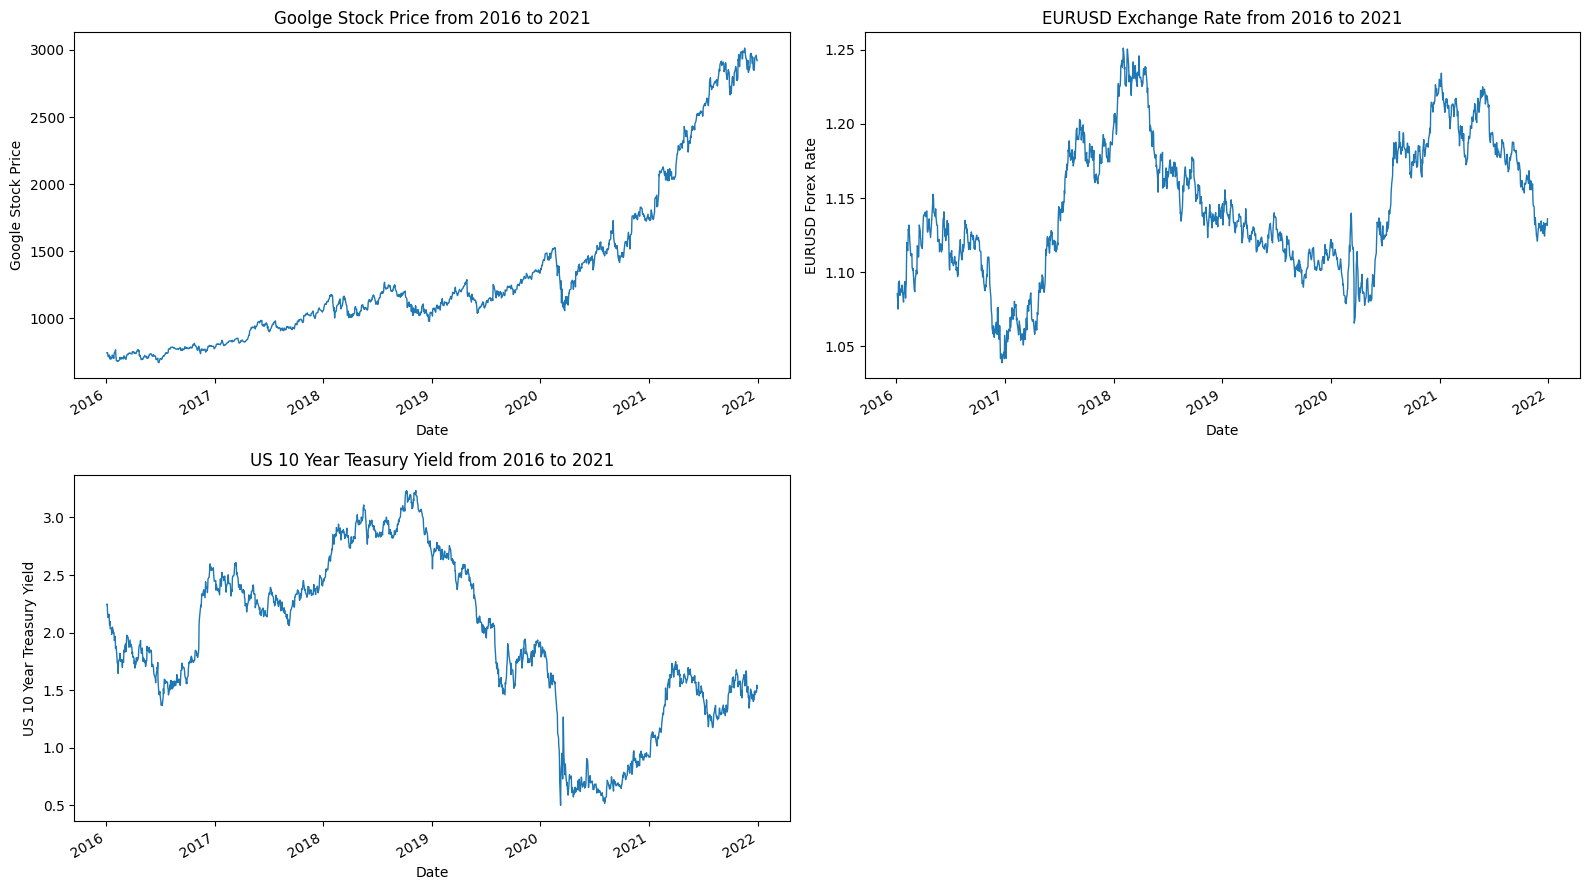

In [1]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arch.unitroot import ADF
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
from statsmodels.tsa.api import VAR


# Download datasets
m6_data = pd.read_csv("Google_eur_usd.csv")

# Convert date variable to date format and set index
m6_data["Date2"] = pd.to_datetime(m6_data["Date"], format="%m/%d/%Y")
data_set = m6_data.loc[:,].set_index("Date2")

# Selecting GOOGLE, EURUSD, UST10Y
goog = data_set.GOOGLE
eur = data_set.EURUSD
ust10 = data_set.UST10Y
plt.rcParams["figure.figsize"] = (16, 9)  # Figure size and width

# Time plots for Google Stock Price, EUR/USD Forex Rate and U.S. 10-Year Treasury Yield
fig, axs = plt.subplots(2, 2)

goog.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Google Stock Price",
    title="Goolge Stock Price from 2016 to 2021",
    ax=axs[0, 0],
)

eur.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="EURUSD Forex Rate",
    title="EURUSD Exchange Rate from 2016 to 2021",
    ax=axs[0, 1],
)

ust10.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="US 10 Year Treasury Yield",
    title="US 10 Year Teasury Yield from 2016 to 2021",
    ax=axs[1, 0],
)

axs[1, 1].axis("off")
fig.tight_layout()
plt.show()

In [2]:
# ADF Test Results with 5% Significance Level for GOOGLE, EURUSD, UST10Y
goog_adf = ADF(goog, trend="n", method="bic")
eur_adf = ADF(eur, trend="n", method="bic")
ust10_adf = ADF(ust10, trend="n", method="bic")

pd.DataFrame(
    {
        "Google Stock Price": (goog_adf.stat, goog_adf.critical_values["5%"]),
        "| EURUSD Forex Rate": (eur_adf.stat, eur_adf.critical_values["5%"]),
        "| US 10 Year Treasury Yield": (
            ust10_adf.stat,
            ust10_adf.critical_values["5%"],
        ),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)

,Google Stock Price,| EURUSD Forex Rate,| US 10 Year Treasury Yield
ADF Test Statistic,3.04790,0.164388,-0.810331
5% Critical Value,-1.94118,-1.941180,-1.941180


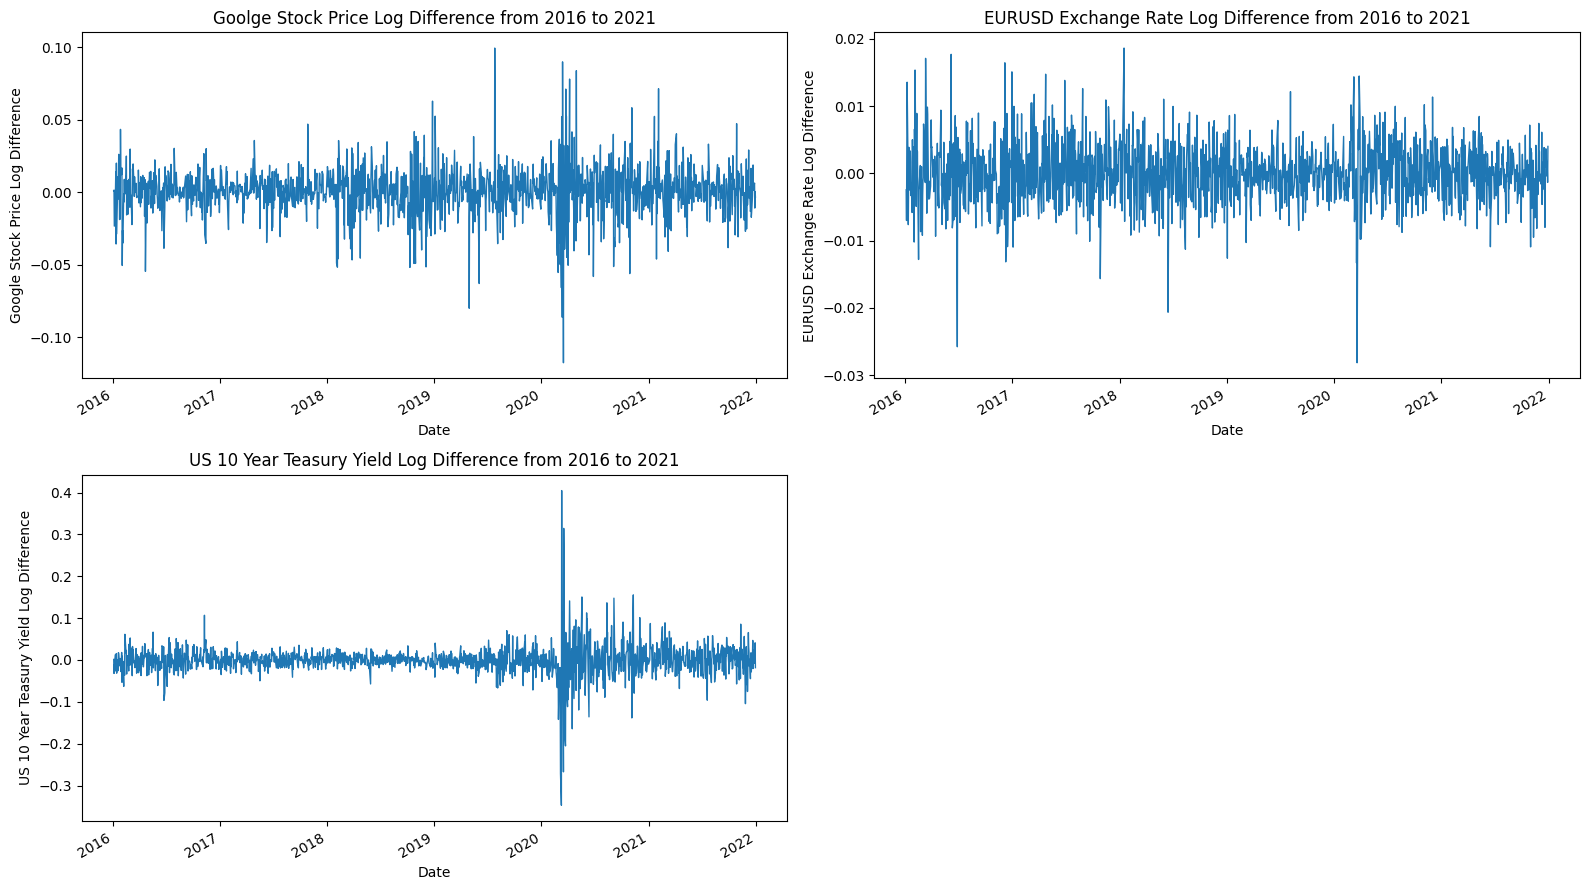

In [3]:
# Time Plots for Differenced GOOGLE, EURUSD, UST10Y
fig, axs = plt.subplots(2, 2)

lgoog = np.log(goog).diff().dropna()
lgoog.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="Google Stock Price Log Difference",
    title="Goolge Stock Price Log Difference from 2016 to 2021",
    ax=axs[0, 0],
)

leur = np.log(eur).diff().dropna()
leur.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="EURUSD Exchange Rate Log Difference",
    title="EURUSD Exchange Rate Log Difference from 2016 to 2021",
    ax=axs[0, 1],
)

lust10 = np.log(ust10).diff().dropna()
lust10.plot(
    linewidth=1,
    xlabel="Date",
    ylabel="US 10 Year Teasury Yield Log Difference",
    title="US 10 Year Teasury Yield Log Difference from 2016 to 2021",
    ax=axs[1, 0],
)

axs[1, 1].axis("off")
fig.tight_layout()
plt.show()

In [4]:
# ADF Test Results with 5% Significance Level for Differenced GOOGLE, EURUSD, UST10Y
lgoog_adf = ADF(lgoog, trend="n", method="bic")
leur_adf = ADF(leur, trend="n", method="bic")
lust10_adf = ADF(lust10, trend="n", method="bic")

pd.DataFrame(
    {
        "Google Stock Price": (lgoog_adf.stat, lgoog_adf.critical_values["5%"]),
        "| EURUSD Forex Rate": (leur_adf.stat, leur_adf.critical_values["5%"]),
        "| US 10 Year Treasury Yield": (
            lust10_adf.stat,
            lust10_adf.critical_values["5%"],
        ),
    },
    index=["ADF Test Statistic", "5% Critical Value"],
)

,Google Stock Price,| EURUSD Forex Rate,| US 10 Year Treasury Yield
ADF Test Statistic,-43.391403,-39.458187,-16.826455
5% Critical Value,-1.941180,-1.941180,-1.941181


In [5]:
# VAR Model Lag Selection for Differenced GOOGLE, EURUSD, UST10Y

# Join log time series in one DataFrame
diff_data = pd.concat([lgoog, leur, lust10], axis=1)

# Fit VAR model and run lag selection tool
model = VAR(diff_data)
x = model.select_order(maxlags=12, trend="c")
x.summary()

C:\Users\p18pr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-25.77,-25.76*,6.404e-12,-25.77
1,-25.80,-25.75,6.260e-12,-25.78*
2,-25.80,-25.72,6.247e-12,-25.77
3,-25.80,-25.70,6.228e-12,-25.76
4,-25.81,-25.67,6.197e-12,-25.76
5,-25.81,-25.64,6.151e-12,-25.75
6,-25.82,-25.62,6.112e-12,-25.75
7,-25.86,-25.63,5.858e-12,-25.78
8,-25.87,-25.60,5.825e-12,-25.77
9,-25.87*,-25.57,5.804e-12*,-25.76


In [6]:
# VAR(1) model for Differenced GOOGLE, EURUSD, UST10Y
diff_mod = VAR(diff_data)
diff_mod_var = diff_mod.fit(
    maxlags=None,
    # when maxlags=None criterion to use for VAR order selection is
    # ic{'aic', 'fpe', 'hqic', 'bic', None}
    ic=None,  # ic=None => automatic lag selection
    method="ols",
    trend="c",
    verbose=True,
)
diff_mod_var.summary()

C:\Users\p18pr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 08, Aug, 2026
Time:                     11:07:33
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.7532
Nobs:                     1503.00    HQIC:                  -25.7799
Log likelihood:           12999.5    FPE:                6.26733e-12
AIC:                     -25.7957    Det(Omega_mle):     6.21756e-12
--------------------------------------------------------------------
Results for equation GOOGLE
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.000992         0.000420            2.362           0.018
L1.GOOGLE        -0.098637         0.026278           -3.754           0.000
L1.EURUSD         0.005368         0.094335            0.057           0.95

In [7]:
# Get the lag order that was selected
lag_order = diff_mod_var.k_ar
print(lag_order)

1


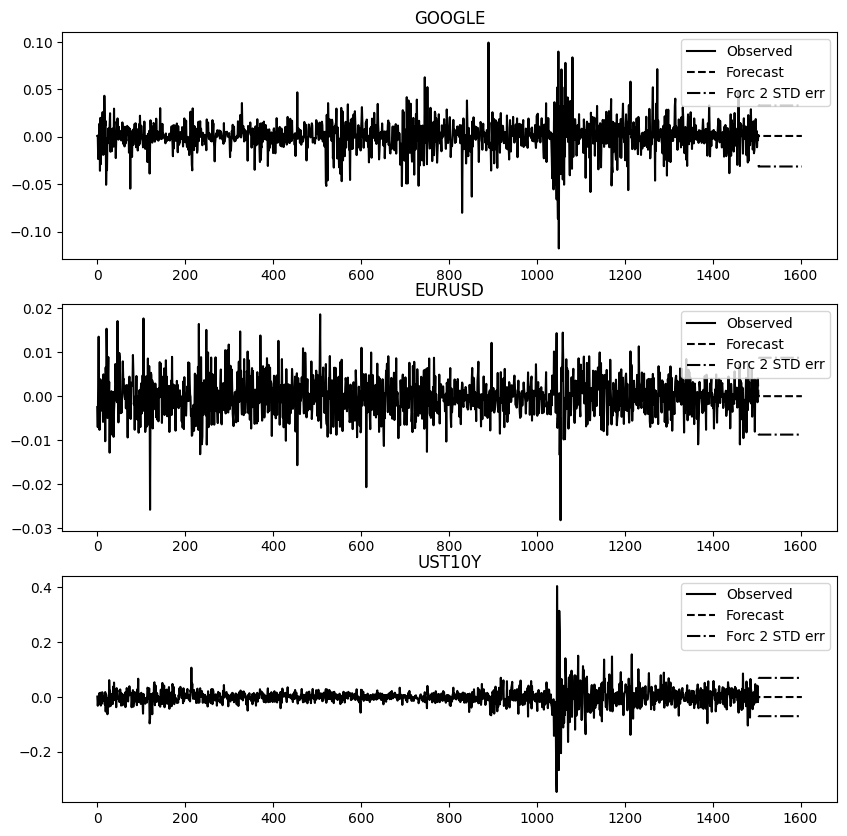

In [8]:
# VAR Model Forecast of the Difference of the Differenced GOOGLE, EURUSD, UST10Y
diff_mod_var.plot_forecast(steps=100, alpha=0.05, plot_stderr=True)
plt.show()

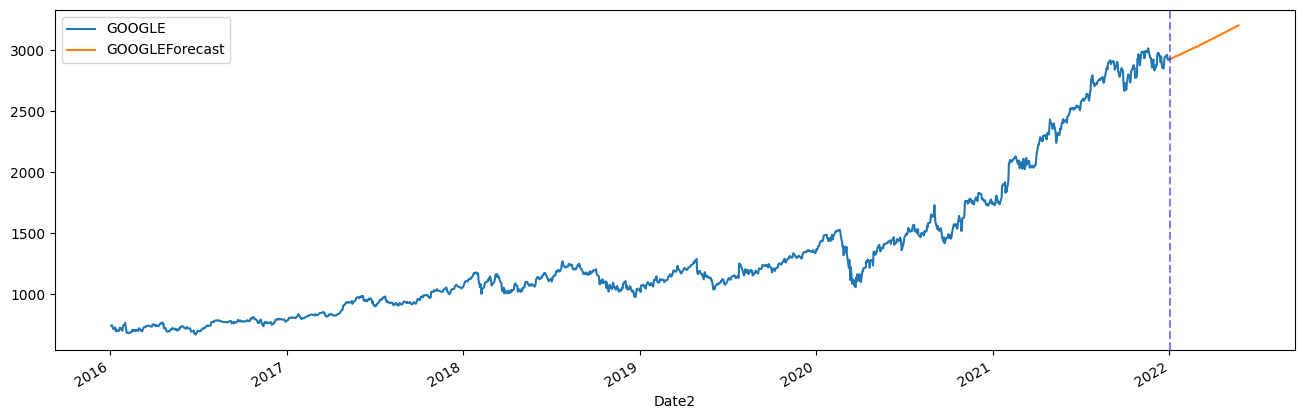

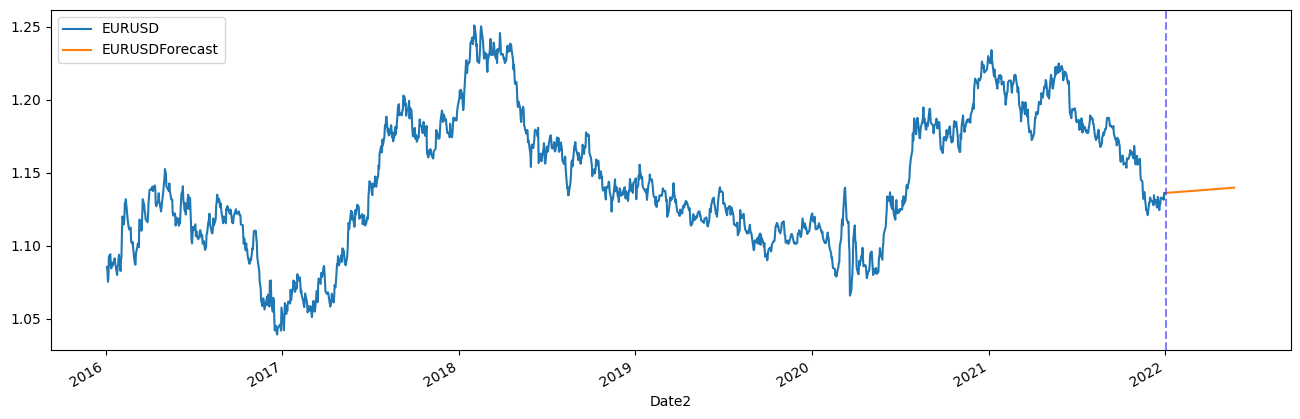

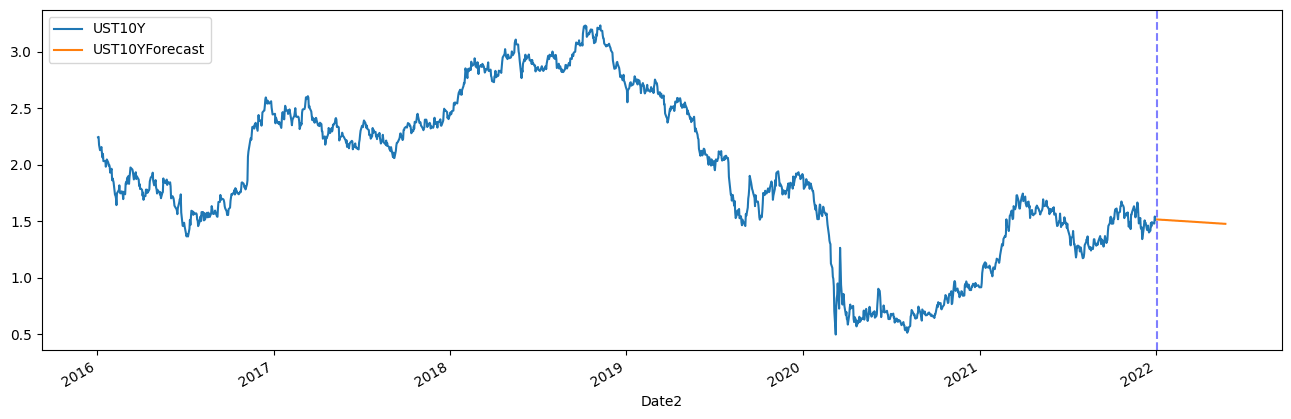

In [9]:
# VAR Model Forecast of Level of GOOGLE, EURUSD, UST10Y

# get 100 step prediction values for differenced data
# drop NA values at start
diff_data_val = diff_data.values[diff_mod_var.k_ar :]  # noQA E203
pred = diff_mod_var.forecast(y=diff_data_val, steps=100)
pd.DataFrame(pred)

# extend index with 100 more business dates per USFederalHolidayCalendar
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
idx = pd.date_range("2022-01-03", periods=100, freq=us_bd)
df_forecast = pd.DataFrame(
    data=pred, index=idx, columns=["GOOGLE1d", "EURUSD1d", "UST10Y1d"]
)

# Get the last log values
last_log_goog = np.log(data_set["GOOGLE"].iloc[-1])
last_log_eur = np.log(data_set["EURUSD"].iloc[-1])  
last_log_ust10 = np.log(data_set["UST10Y"].iloc[-1])

# Convert log-differences to log-levels by cumulative sum
df_forecast["GOOGLE_log_level"] = last_log_goog + df_forecast["GOOGLE1d"].cumsum()
df_forecast["EURUSD_log_level"] = last_log_eur + df_forecast["EURUSD1d"].cumsum()
df_forecast["UST10Y_log_level"] = last_log_ust10 + df_forecast["UST10Y1d"].cumsum()

# Convert log-levels back to original levels using exponential
df_forecast["GOOGLEForecast"] = np.exp(df_forecast["GOOGLE_log_level"])
df_forecast["EURUSDForecast"] = np.exp(df_forecast["EURUSD_log_level"])
df_forecast["UST10YForecast"] = np.exp(df_forecast["UST10Y_log_level"])


# plot initial data with forecasted values for each of GOOGLE, EURUSD, UST10Y
data_set["GOOGLE"].plot(figsize=(16, 5), legend=True)
df_forecast["GOOGLEForecast"].plot(legend=True)
plt.axvline(x="2022-01-03", color="b", alpha=0.5, linestyle="--")
plt.show()

data_set["EURUSD"].plot(figsize=(16, 5), legend=True)
df_forecast["EURUSDForecast"].plot(legend=True)
plt.axvline(x="2022-01-03", color="b", alpha=0.5, linestyle="--")
plt.show()

data_set["UST10Y"].plot(figsize=(16, 5), legend=True)
df_forecast["UST10YForecast"].plot(legend=True)
plt.axvline(x="2022-01-03", color="b", alpha=0.5, linestyle="--")
plt.show()